#Financial Distress & Household Debt Stress Prediction

## EDA

### 1. Libraries and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visualization style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
palette = 'viridis'

In [ ]:
#reading dataset
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 2. Data Inspection (Shape, Nulls, Describe)

In [ ]:
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (32581, 12)

Missing Values per Column:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Statistical Summary:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64




### 3.Univariate Analysis
Exploring the distributions, patterns, potential outliers, skewness of  features.

#### Age Distribution

In [ ]:
def age_group(arr):
    for i in range(len(arr) - 1):
        lower = arr[i]
        upper = arr[i + 1]

        num_people = ((df['person_age'] > lower) & (df['person_age'] <= upper)).sum()
        print(f"Age between {lower} and {upper}: {num_people}")

    # last group
    last = arr[-1]
    num_people = (df['person_age'] > last).sum()
    print(f"Age above {last}: {num_people}")

maximum Age 144
minimum Age 20
Age between 0 and 18: Number of people 0
Age between 18 and 26: Number of people 17829
Age between 26 and 36: Number of people 14311
Age between 36 and 46: Number of people 2908
Age between 46 and 56: Number of people 528
Age between 56 and 66: Number of people 113


- The applicant age ranges from **20 to 144**, with the majority concentrated in the **21–35 age group**, which reflects a younger, loan-seeking demographic.
- The extreme drop-off after age 40 and the presence of values above 100 confirm that **ages above 100 are data entry errors** and will be removed during preprocessing.

#### Distribution of Income

In [ ]:
#max and min income
max_ = df['person_income'].max()
min_ = df['person_income'].min()

print(f"maximum Income {max_}")
print(f"minimum Income {min_}")

#people with an income between x and y
def income_group(arr):
    for i in range(len(arr) - 1):
        lower = arr[i]
        upper = arr[i + 1]

        num_people = df['person_income'].between(lower, upper, inclusive='left').sum()

        print(f"Income between {lower} and {upper}: Number of people {num_people}")

income_group([0, 25000, 50000, 75000, 100000, float('inf')])

maximum Income 6000000
minimum Income 4000
Income between 0 and 25000: Number of people 2243
Income between 25000 and 50000: Number of people 11061
Income between 50000 and 75000: Number of people 9821
Income between 75000 and 100000: Number of people 4886
Income between 100000 and inf: Number of people 4570


The distribution is **heavily right-skewed** — a small number of applicants earn well above the typical range. Rather than removing these values (which could be legitimate high earners), a **log1p transformation** is applied during preprocessing to compress the scale and reduce the influence of extreme values without discarding information.

#### Distribution of Home Ownership

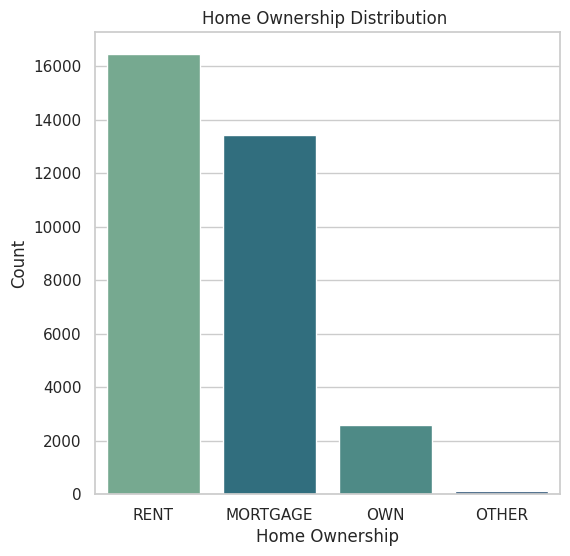

In [ ]:
plt.figure(figsize=(6,6))

order = df["person_home_ownership"].value_counts().index

sns.countplot(
    x="person_home_ownership",
    data=df,
    order=order,
    hue="person_home_ownership",
    palette="crest"
)

plt.title("Home Ownership Distribution ")
plt.xlabel("Home Ownership")
plt.ylabel("Count")

plt.show()

- The majority of applicants either **rent** or have a **mortgage**, meaning over 90% do not fully own their home. This aligns with the loan-seeking profile — people who rent or have mortgages are more likely to need additional credit.

- Only a few own their home outright, and a negligible applicants fall under "OTHER". The "OTHER" category will be kept as a valid group since removing it could discard real applicants.

#### Loan Intent

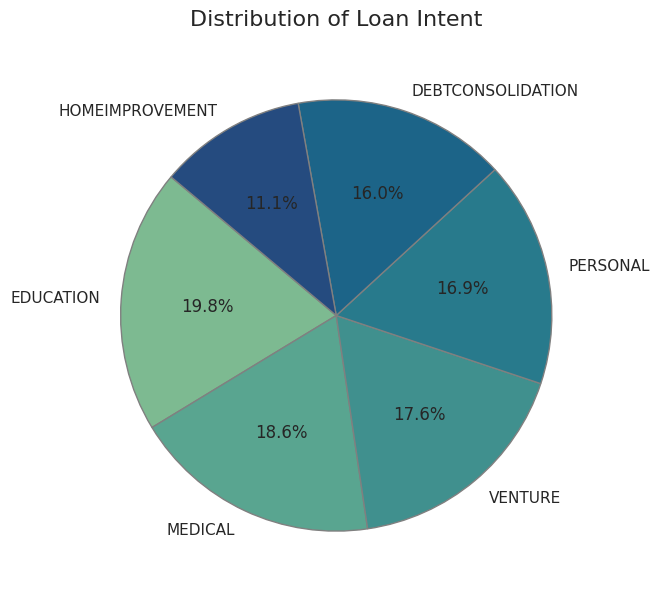

In [ ]:
loan_counts = df["loan_intent"].value_counts()

colors = sns.color_palette("crest", n_colors=len(loan_counts))

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    loan_counts.values,
    labels=loan_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'gray', 'linewidth':1})

plt.title("Distribution of Loan Intent", fontsize=16, pad=15)
plt.show()

- Loan purposes are fairly evenly distributed across six categories, with **Education (19.8%)** and **Medical (18.6%)** being the most common. This suggests the dataset captures a diverse borrowing population rather than being biased toward a single use case
- All six intent categories will be **one-hot encoded** since there is no natural ordinal relationship between them.

#### Loan Grades

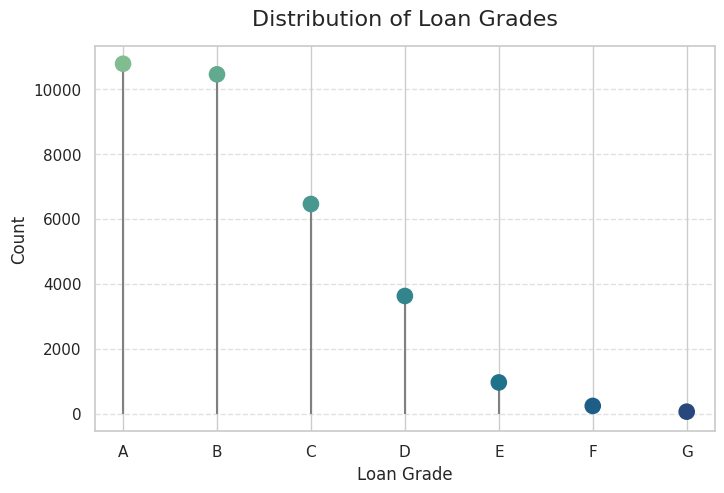

In [ ]:
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
grade_counts = df["loan_grade"].value_counts().reindex(grade_order)

# Colors
colors = sns.color_palette("crest", n_colors=len(grade_counts))

plt.figure(figsize=(8,5))

# Stem lines
plt.stem(grade_counts.index, grade_counts.values, basefmt=" ", linefmt="gray")

# Circles
plt.scatter(grade_counts.index, grade_counts.values, s=120, c=colors, zorder=3)

# Styling
plt.title("Distribution of Loan Grades", fontsize=16, pad=15)
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


- Loan grades follow a **decreasing distribution from A to G**, with grades A and B accounting for the majority of applicants. This reflects the standard credit grading reality where most applicants are lower-risk.

- Grades E, F, and G together represent fewer applicants — rare but critical segments for default prediction. The strong monotonic relationship between grade and risk makes this an ideal candidate for **ordinal encoding (A=1 through G=7)**, preserving the meaningful risk ordering.

#### Loan Amount

In [ ]:
max_loan_amount = df['loan_amnt'].max()
min_loan_amount = df['loan_amnt'].min()

print(f"maximum Loan Amount {max_loan_amount}")
print(f"minimum Loan Amount {min_loan_amount}")

# people with an income between x and y
def loan_amount_group(arr):
    for i in range(len(arr) - 1):
        lower = arr[i]
        upper = arr[i + 1]

        num_people = df['loan_amnt'].between(lower, upper, inclusive='left').sum()

        print(f"Loan Amount between {lower} and {upper}: Number of people {num_people}")

loan_amount_group([0, 5000, 10000, 15000, float('inf')])

maximum Loan Amount 35000
minimum Loan Amount 500
Loan Amount between 0 and 5000: Number of people 7446
Loan Amount between 5000 and 10000: Number of people 11419
Loan Amount between 10000 and 15000: Number of people 7285
Loan Amount between 15000 and inf: Number of people 6431


- Loan amounts range from **500 to 35,000**, with most applicants requesting between **5,000 and 10,000**. The distribution is moderately right-skewed — a larger number of smaller loans and fewer large ones.

- This skewness, while less extreme than income, still benefits from a **log1p transformation** during preprocessing to normalise the scale for distance-based and linear models.


#### Distribution of features

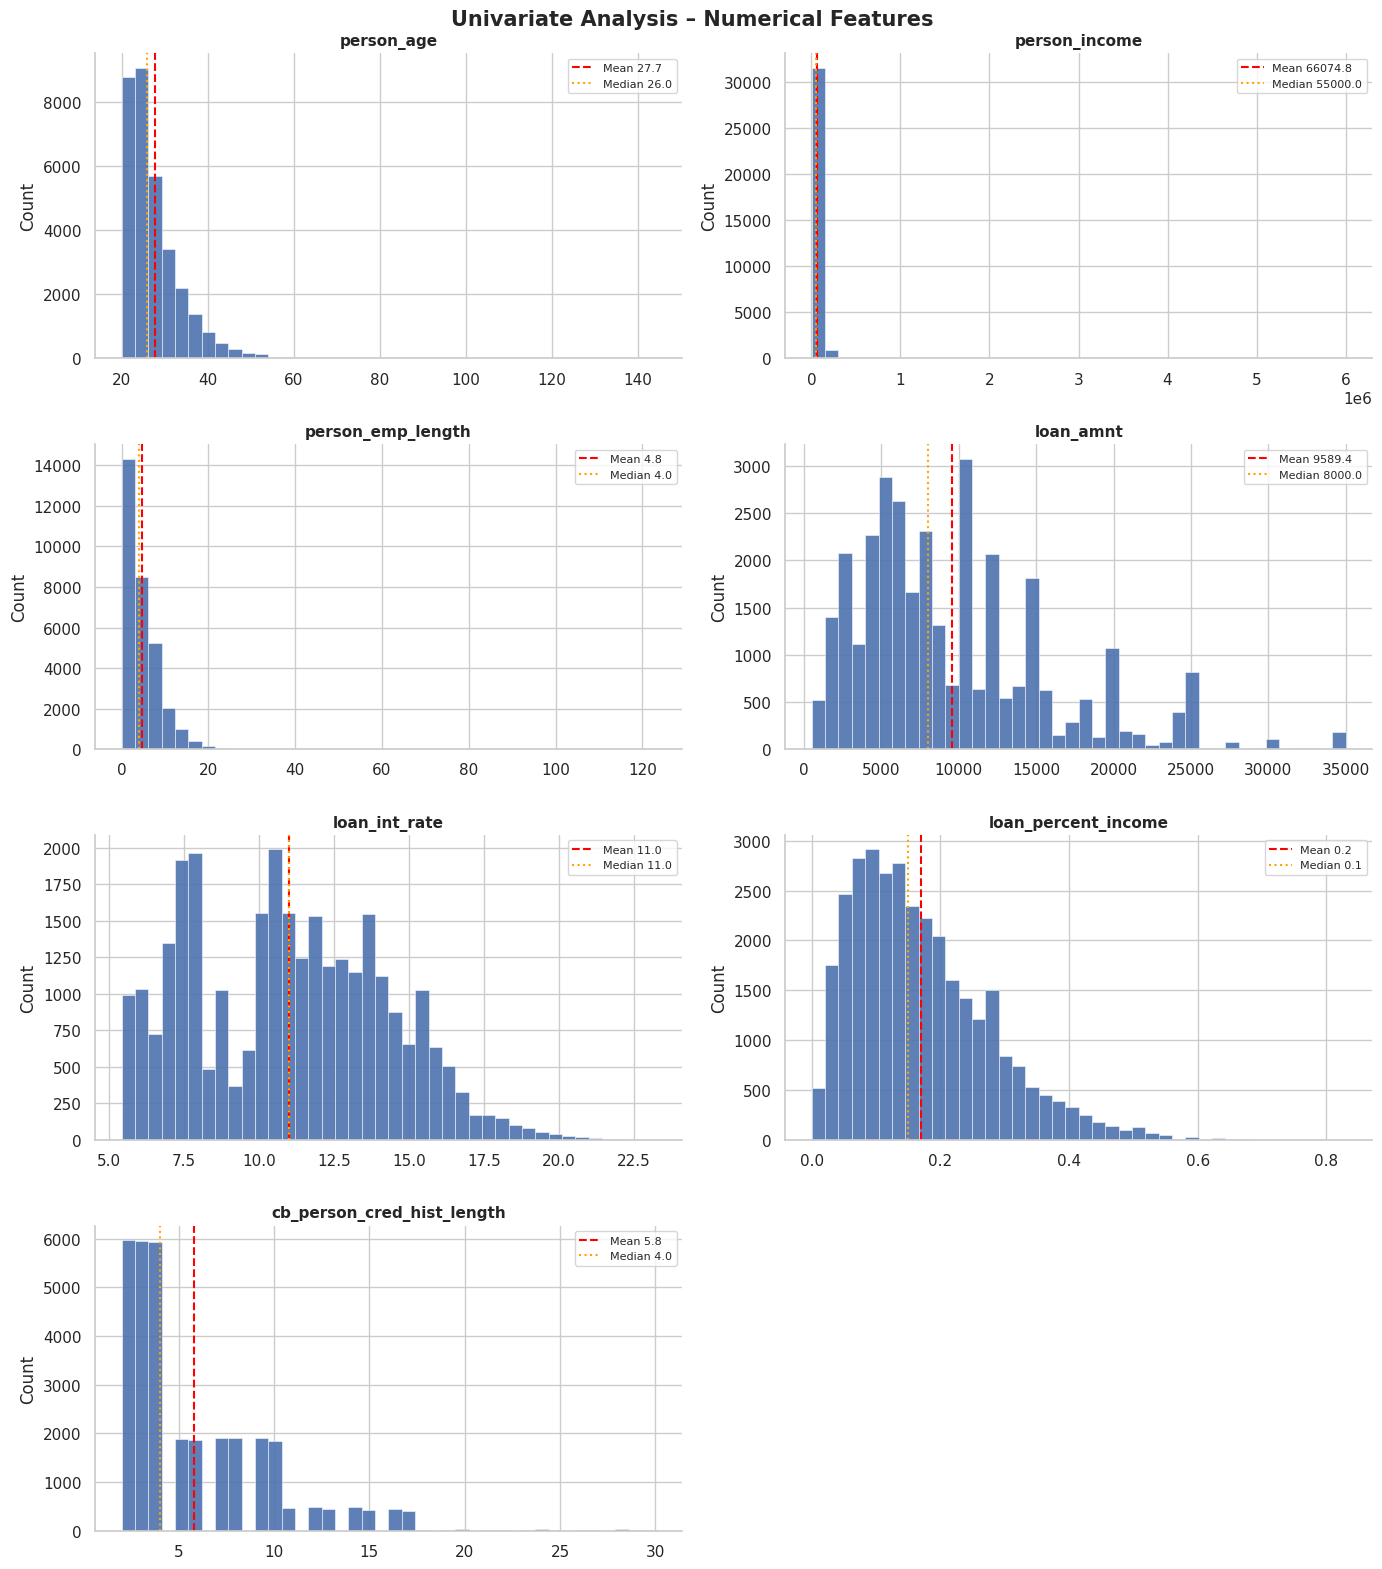

In [ ]:
TARGET   = "loan_status" #for plot
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns
            if c != TARGET]

CLR_NO  = "#4C72B0"   # loan_status = 0  (No Default)
CLR_YES = "#DD8452"   # loan_status = 1  (Default)
PALETTE = [CLR_NO, CLR_YES]



fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle("Univariate Analysis – Numerical Features",
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax   = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=40, color=CLR_NO,
            edgecolor='white', linewidth=0.4, alpha=0.9)

    mean_v, med_v = data.mean(), data.median()
    ax.axvline(mean_v, color='red',    linestyle='--', lw=1.5,
               label=f'Mean {mean_v:.1f}')
    ax.axvline(med_v,  color='orange', linestyle=':',  lw=1.5,
               label=f'Median {med_v:.1f}')

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel("Count")
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

# Hide any spare subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

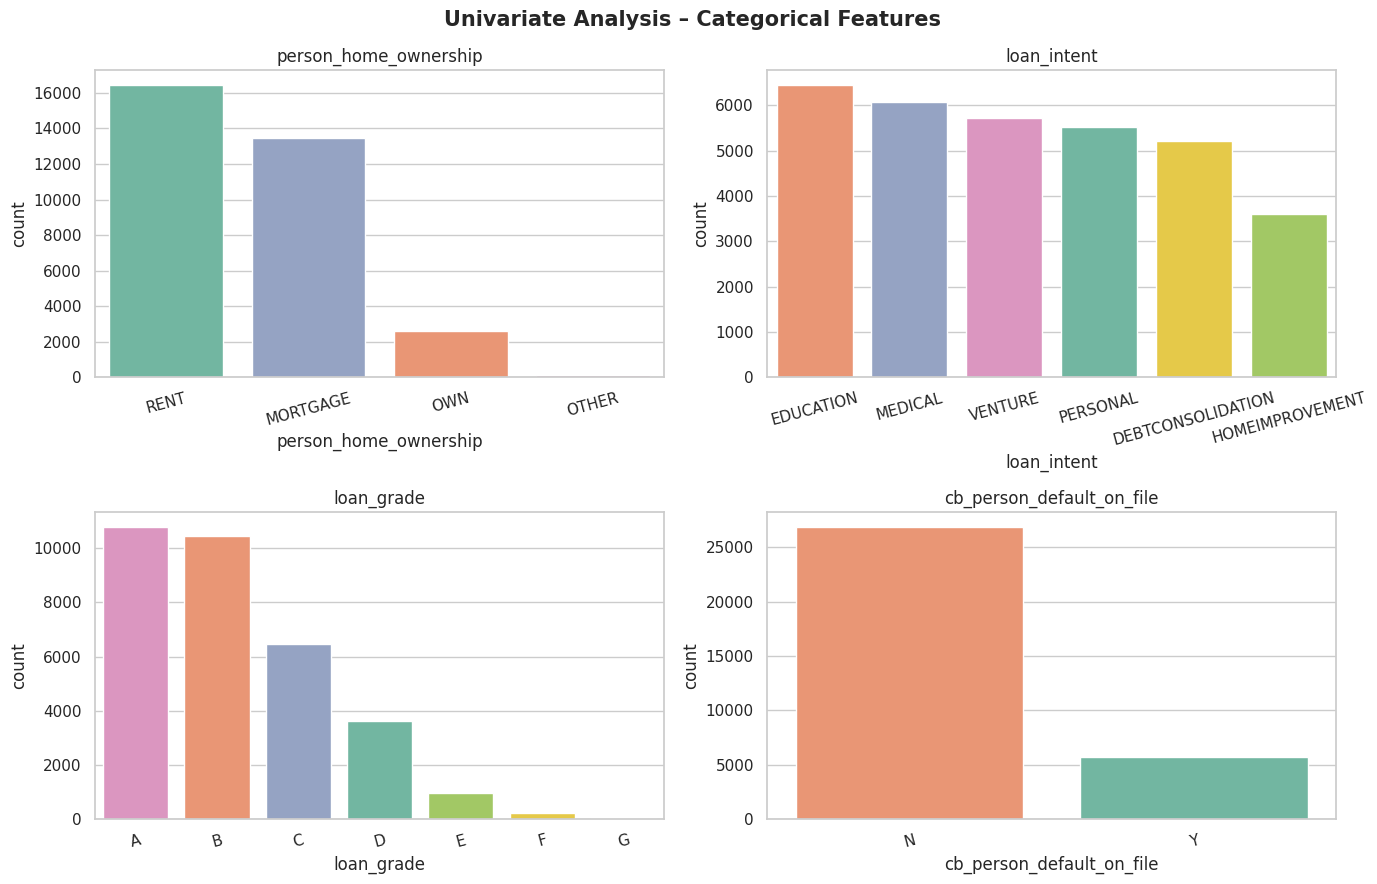

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Univariate Analysis – Categorical Features",fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Sorting
    order = df[col].value_counts().index

    sns.countplot(
        x=col,
        data=df,
        order=order,
        hue=col,
        palette="Set2",
        ax=ax
    )

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

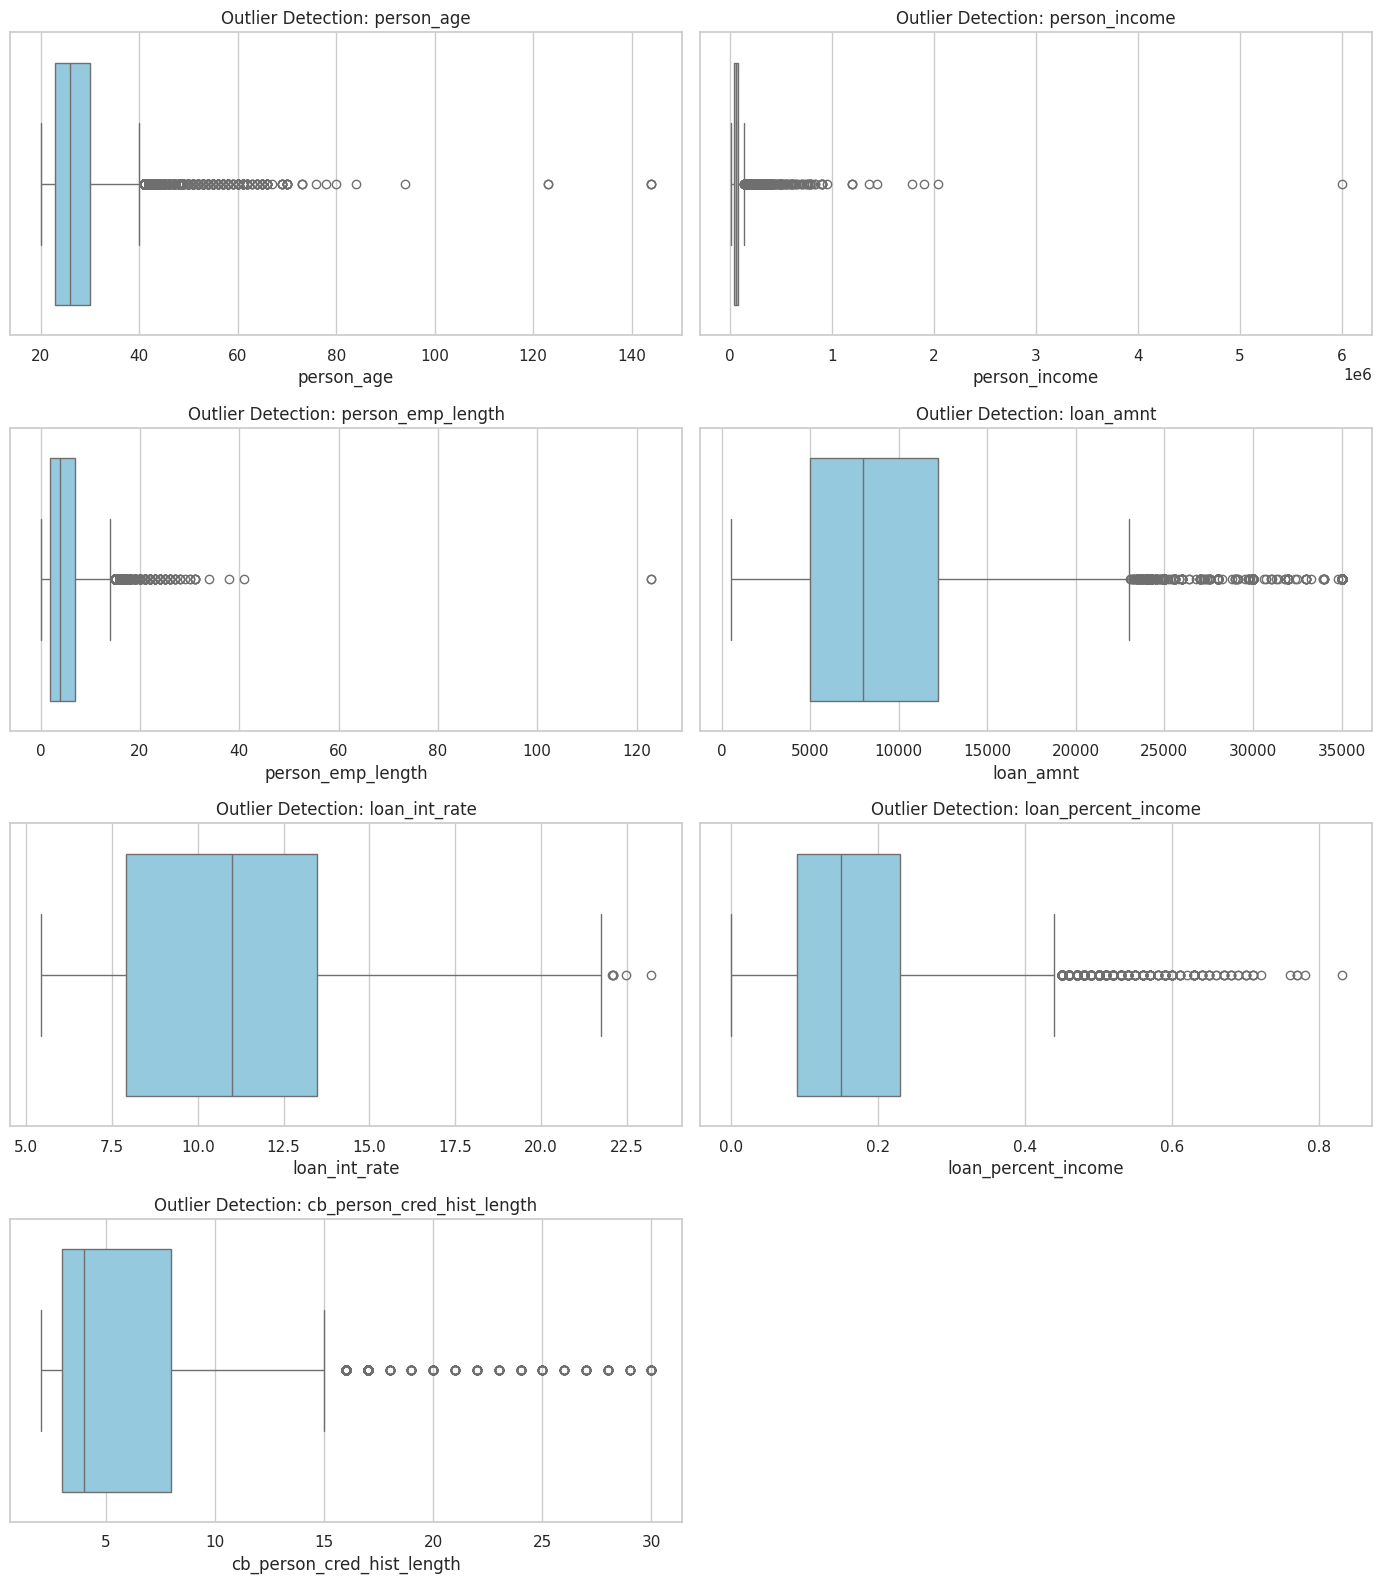

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
            sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f'Outlier Detection: {col}', fontsize=12)

if len(num_cols) < len(axes): fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

- **person_age**: Extreme outliers above 100 (up to 144) — biologically impossible values will be removed.
- **person_emp_length**: Values above 50 years are unrealistic for a working career; values exceeding `person_age - 16` (minimum working age) are logically impossible and will be dropped.
- **person_income**: Severe right skew with values in the millions. These are not necessarily errors — a log transform is the appropriate response rather than removal.
- **loan_int_rate** and **loan_amnt**: Moderate outliers that are plausible in a real lending context and are handled by log transformation.

### 4.Bivariate Analysis
Analyzing how features relate to the target variable `loan_status`.

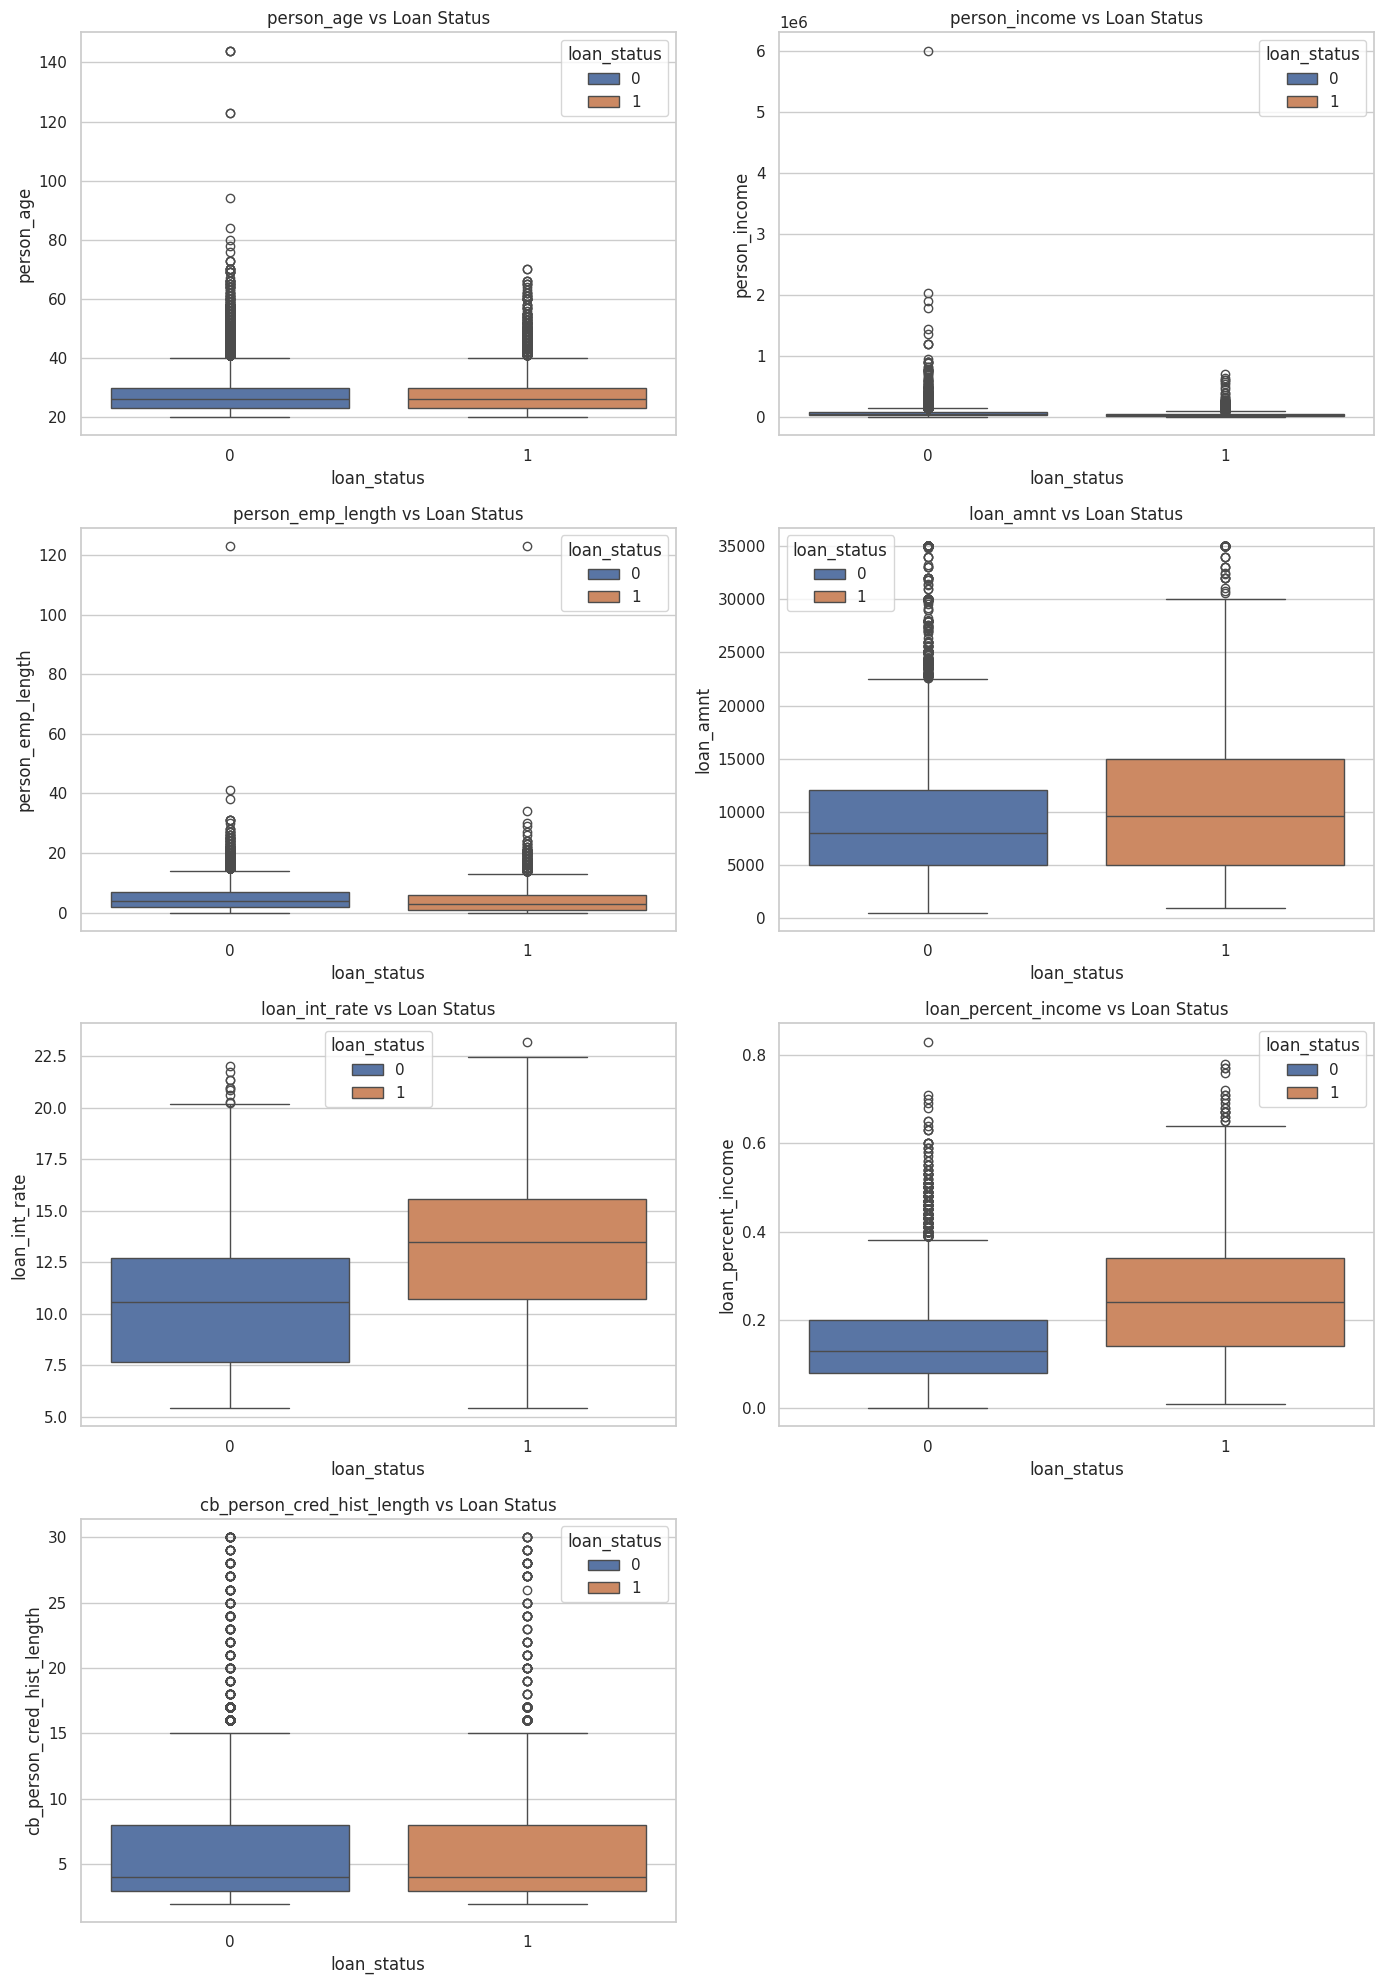

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,20))
axes = axes.flatten()

for i ,col in enumerate(num_cols):
  sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i],hue='loan_status', palette=PALETTE)
  axes[i].set_title(f'{col} vs Loan Status', fontsize=12)
if len(num_cols) < len(axes):
   fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

- **loan_int_rate**: Defaulters have noticeably **higher median interest rates** —  higher-risk applicants receive higher rates, and those high rates correlate with eventual default.
- **loan_percent_income**: Defaulters carry **higher loan-to-income ratios** — they are borrowing a larger share of their income, increasing repayment strain.
- **loan_grade**: Lower grades (higher numeric encoding) show higher default.
- **person_age**, **cb_person_cred_hist_length**: Distributions are nearly identical for both classes — confirming **low individual predictive power** for these features.

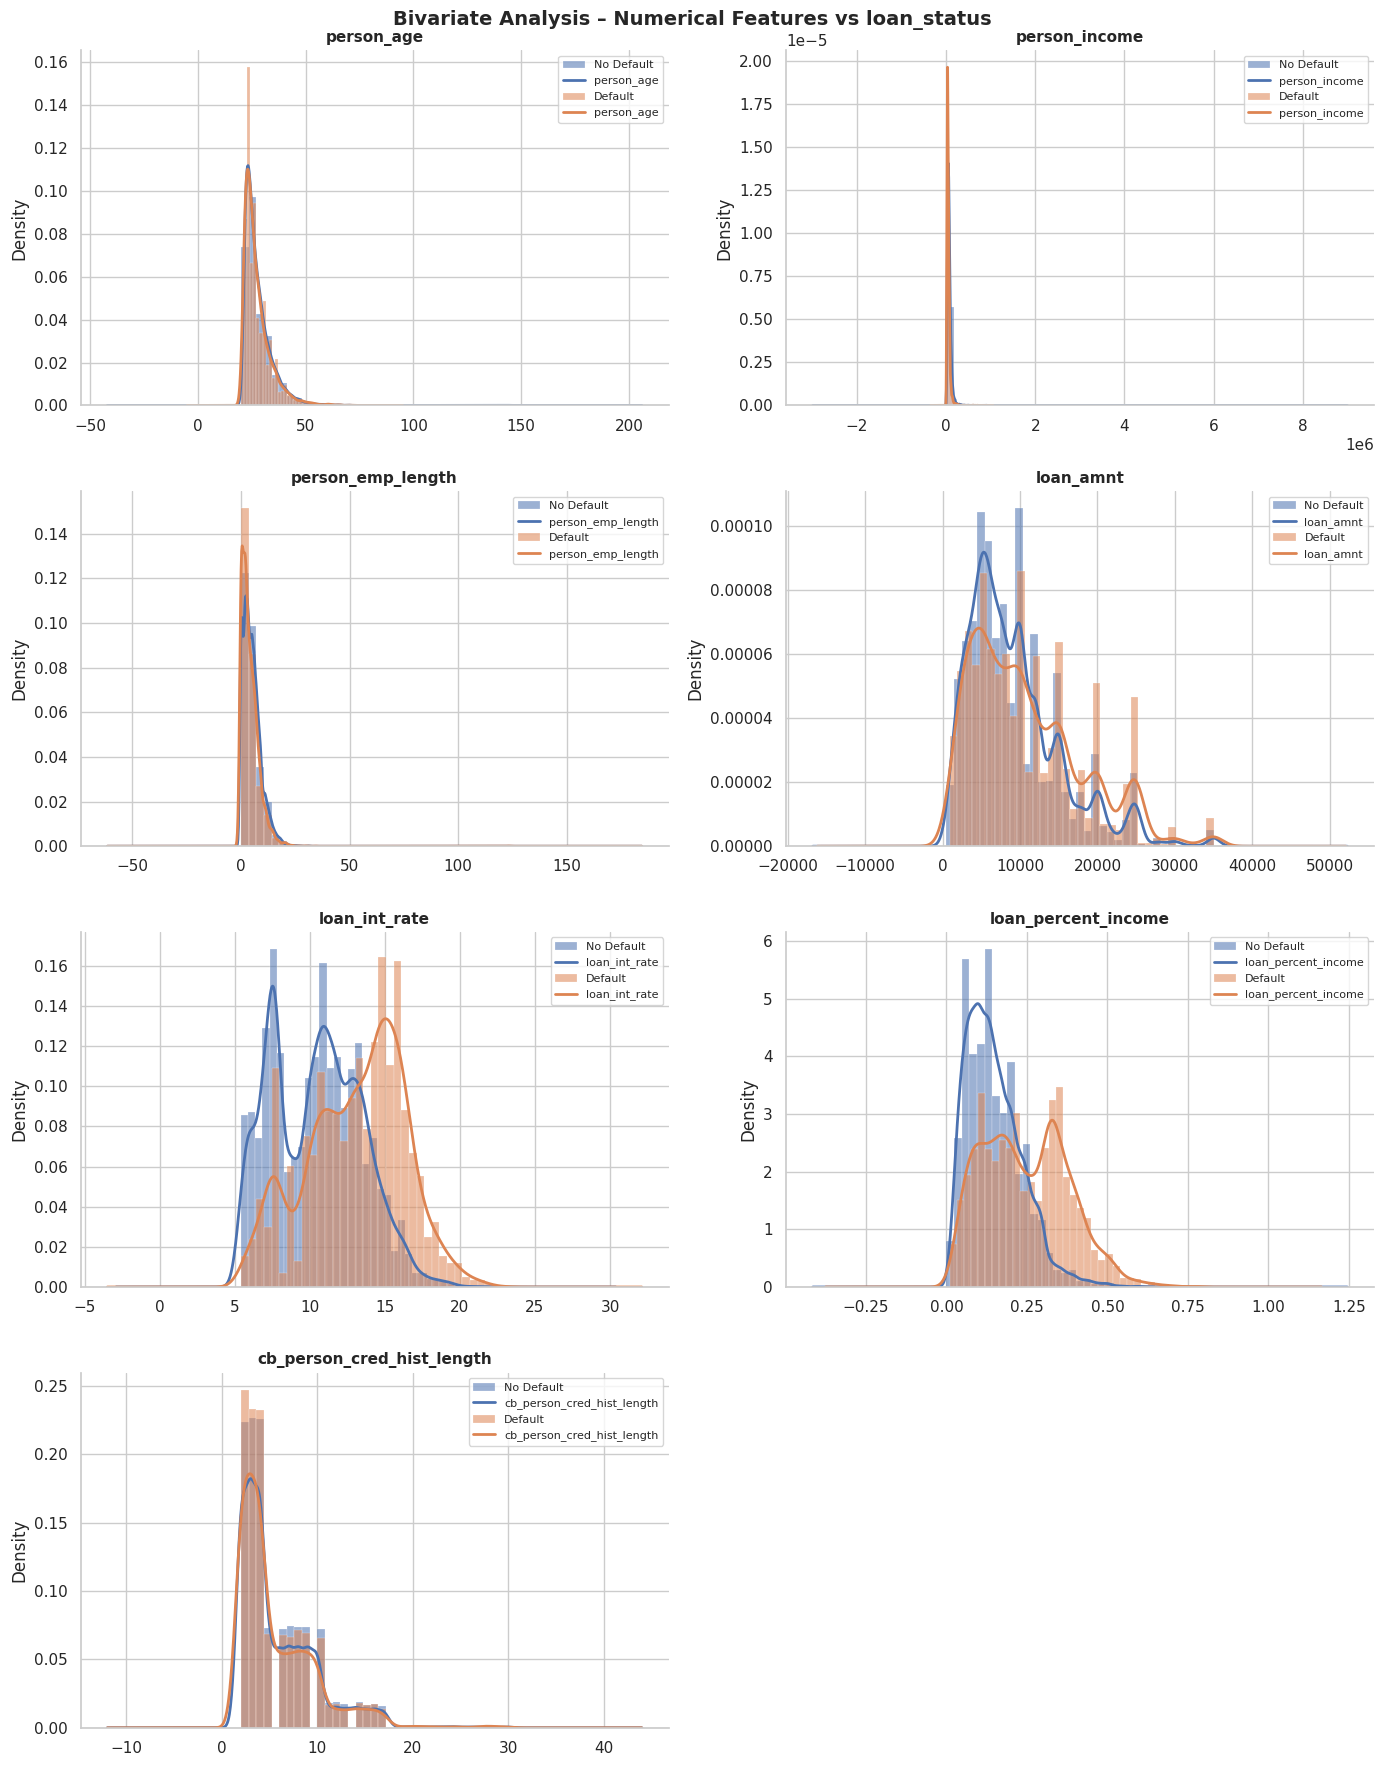

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle("Bivariate Analysis – Numerical Features vs loan_status",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]

    for val, color, label in zip([0, 1], PALETTE, ['No Default', 'Default']):
        subset = df[df[TARGET] == val][col].dropna()

        # Density histogram
        ax.hist(subset, bins=35, alpha=0.55, color=color, label=label,
                density=True, edgecolor='white', linewidth=0.3)
        # KDE overlay
        subset.plot.kde(ax=ax, color=color, lw=2)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel("Density")
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("plot4_bivariate_numerical.png", dpi=140, bbox_inches='tight')
plt.show()

- **loan_int_rate**: Bimodal distribution — one peak around 8–10% (low-risk) and another around 13–15% (high-risk). Defaulters are concentrated in the higher peak.
- **loan_percent_income**: Default distribution is shifted right, confirming that higher debt burden relative to income is a strong default signal.
- **person_income**: Lower-income applicants show slightly higher default density, but there is significant overlap — income alone is not sufficient for prediction.
- **person_age** and **cb_person_cred_hist_length**: Near-identical KDE curves for both classes — minimal discriminatory power when used alone.

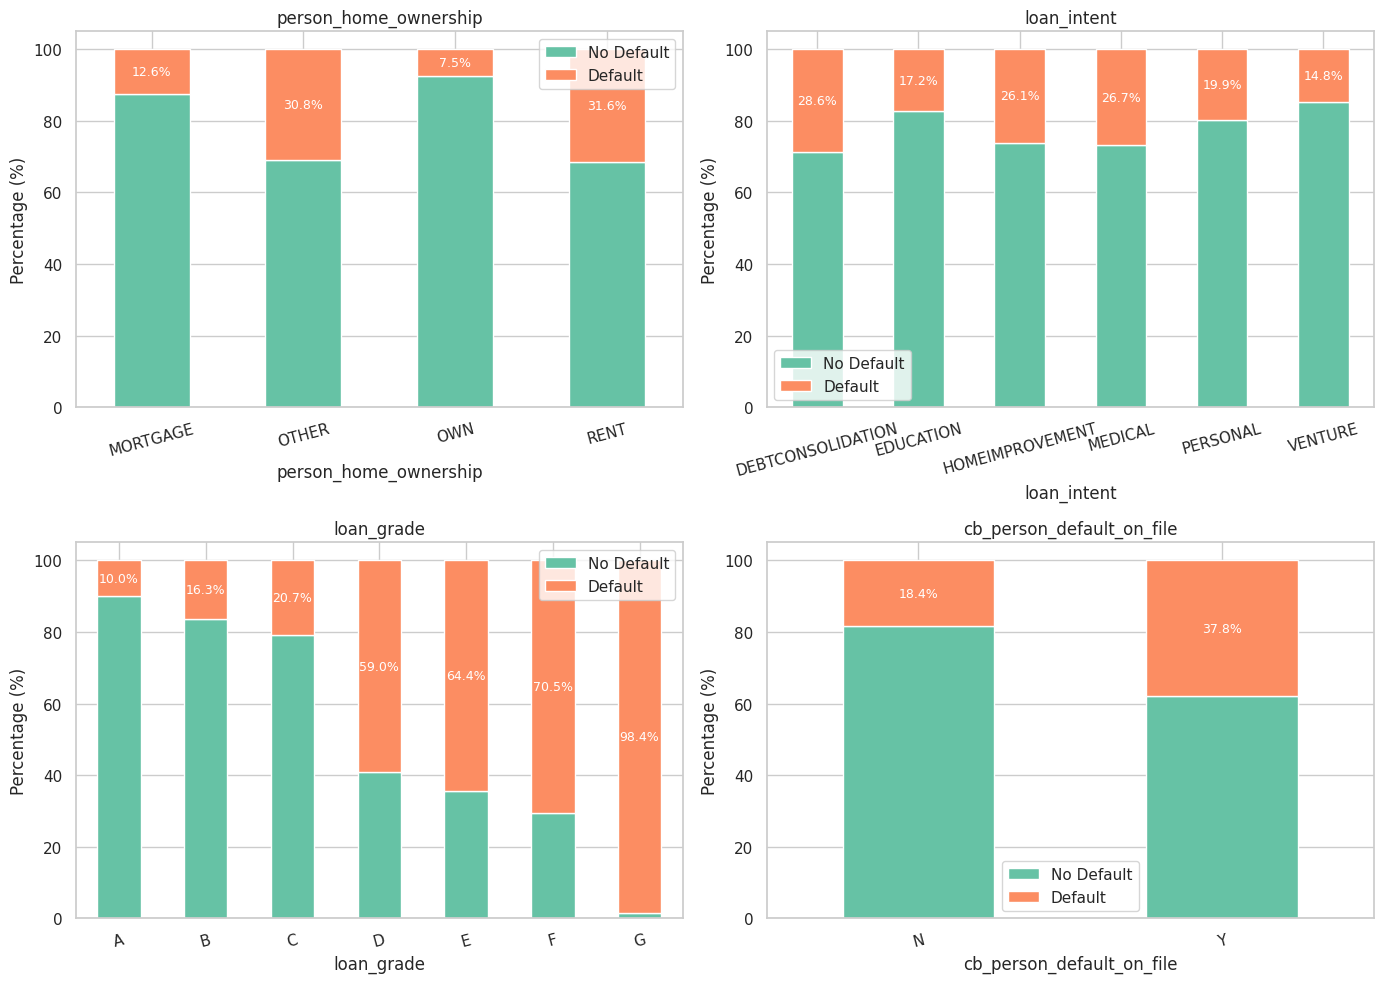

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    #percentage table
    ct = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    ct.columns = ['No Default', 'Default']

    # Plot
    ct.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=['#66c2a5', '#fc8d62']
    )

    ax.set_title(col)
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis='x', rotation=15)

    for j, row in enumerate(ct.values):
            ax.text(j, row[0] + row[1]/2,
            f"{row[1]:.1f}%",
            ha='center', va='center',
            color='white', fontsize=9)

plt.tight_layout()
plt.show()

- **loan_grade**: The most powerful categorical predictor. Default rate escalates steeply from **~5% at Grade A** to over **60% at Grade G**. This  relationship strongly supports ordinal encoding.
- **cb_person_default_on_file**: Applicants with a prior default on record show a **notably higher default rate** versus those without . Prior default history is a proven credit risk signal used in real-world scoring.
- **loan_intent**: Relatively flat across categories, but **VENTURE and PERSONAL** intents show marginally higher default rates. Medical and education loans show slightly lower rates, possibly reflecting borrower necessity and commitment.
- **person_home_ownership**: RENT and OTHER categories show slightly higher default rates than MORTGAGE or OWN — likely reflecting lower financial stability among renters.

### Correlation Heatmap

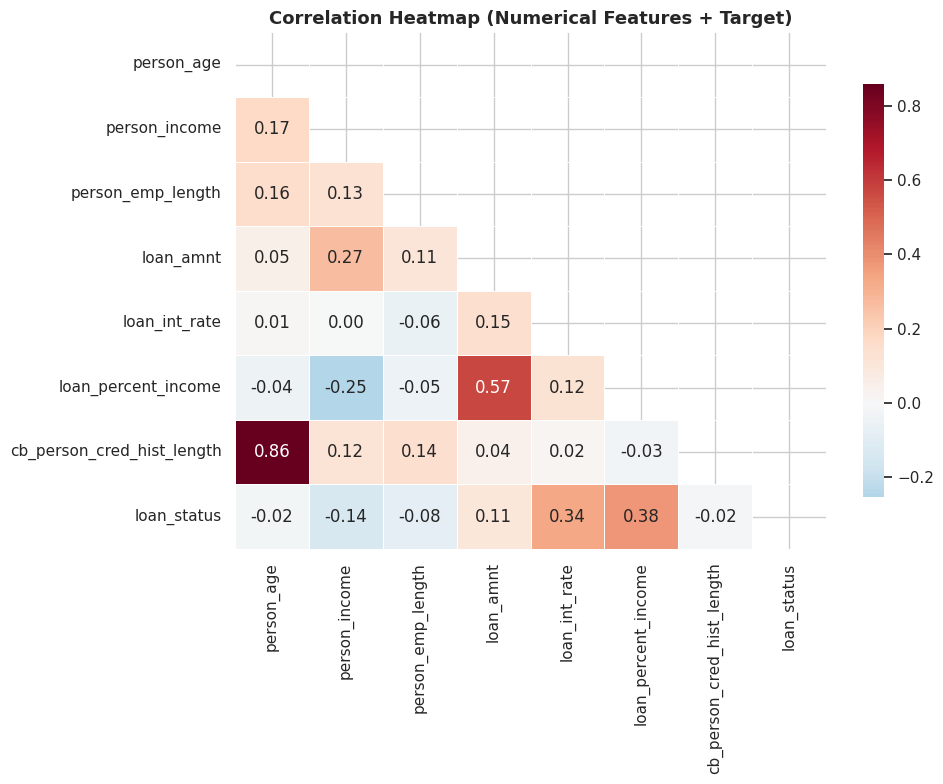

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_df = df[num_cols + [TARGET]].corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))  # hide upper triangle

sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title("Correlation Heatmap (Numerical Features + Target)",
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("plot6_correlation_heatmap.png", dpi=140, bbox_inches='tight')
plt.show()

Key correlations with the target (`loan_status`):

| Feature | Correlation with loan_status | Interpretation |
|---------|------------------------------|----------------|
| loan_int_rate | **+0.34** |moderate positive relationship |
| loan_percent_income | **+0.38** | moderate positive relationship |
| cb_person_cred_hist_length | -0.02 | Negligible relationship |
| person_age | -0.02 | Negligible relationship |

**Multicollinearity concern:**
- `person_age` and `cb_person_cred_hist_length` are correlated at **~0.86** — older people naturally have longer credit histories.
- `loan_amnt` and `loan_percent_income` are correlated at **~0.57** — expected, as larger loans represent a larger income fraction.

### Target Variable Distribution

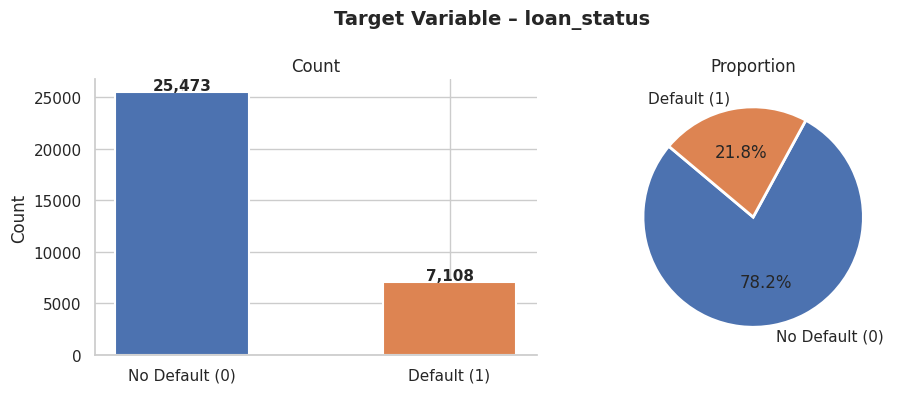

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Target Variable – loan_status", fontsize=14, fontweight='bold')

counts = df[TARGET].value_counts().sort_index()
labels = ["No Default (0)", "Default (1)"]

# Bar chart
axes[0].bar(labels, counts.values, color=PALETTE,
            edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_title("Count")
axes[0].set_ylabel("Count")
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Proportion")

plt.tight_layout()
plt.savefig("plot1_target_distribution.png", dpi=140, bbox_inches='tight')
plt.show()

### 5. Summary of Key Findings

**Data Health & Structure**
* The dataset contains **32,581 records**.
* Missing values are present in `person_emp_length` (895) and `loan_int_rate` (3,116).
* The target variable `loan_status` is imbalanced, with roughly **21.8%** of the dataset representing defaults.

**Statistical Insights**
* **Strong Numerical Indicators:** Both `loan_int_rate` and `loan_percent_income` show clear shifts in distribution for defaulters. Defaulters typically have higher interest rates and higher loan-to-income ratios.
* **Strong Categorical Indicators:** `loan_grade` is highly predictive; as grades move from A toward G, the default probability increases significantly.
* **Lower Variance Features:** `person_age` and `cb_person_cred_hist_length` show very similar medians and distributions for both groups, suggesting lower predictive power in isolation.

## Preprocessing

### Duplicated Rows

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("New shape after removing duplicates:", df.shape)

Duplicate rows: 165
New shape after removing duplicates: (32416, 12)


In [ ]:
# Check rows with unrealistic values before cleaning
print("Rows with age > 100 before cleaning:", (df['person_age'] > 100).sum())
print("Rows with emp_length > 50 before cleaning:", (df['person_emp_length'] > 50).sum())
print("Rows violating age-emp logic before cleaning:",
      (df['person_emp_length'] > df['person_age'] - 16).sum())

# Drop age > 100
df = df[df['person_age'] <= 100]

# Drop emp_length > 50
mask_emp50 = df['person_emp_length'].isna() | (df['person_emp_length'] <= 50)
df = df[mask_emp50]

# Drop impossible age-emp logic
mask_logic = df['person_emp_length'].isna() | (df['person_emp_length'] <= df['person_age'] - 16)
df = df[mask_logic]

# Verify after cleaning
print("\nAfter cleaning:")
print("Rows with age > 100:", (df['person_age'] > 100).sum())
print("Rows with emp_length > 50:", (df['person_emp_length'] > 50).sum())
print("Rows violating age-emp logic:",
      (df['person_emp_length'] > df['person_age'] - 16).sum())
print("NaN emp_length retained:", df['person_emp_length'].isna().sum())
print(f"Total rows after cleaning: {len(df)}")

Rows with age > 100 before cleaning: 5
Rows with emp_length > 50 before cleaning: 2
Rows violating age-emp logic before cleaning: 737

After cleaning:
Rows with age > 100: 0
Rows with emp_length > 50: 0
Rows violating age-emp logic: 0
NaN emp_length retained: 887
Total rows after cleaning: 31674


1. **Age > 100 removed**: Values like 144 are biologically impossible and represent data entry errors. A threshold of 100 is conservative —  Only **5 rows** were removed.

2. **Employment length > 50 removed**: 50 years represents a full working career (e.g., starting at 18, retiring at 68). Values beyond this are inconsistent. **2 rows** were removed.

3. **Employment length > age − 16 removed**: A person cannot have worked longer than they have been of working age (assumed 16). For example, a 25-year-old cannot have 20 years of employment history. **~740 rows** were removed. Crucially, rows where `person_emp_length` is **NaN are kept** — ensures valid missing values are not incorrectly dropped and are later imputed by the pipeline.

**Total rows removed in this step**: ~747. No valid data was lost

In [ ]:
print(df.isna().sum())
print(df['person_age'].max())
print(df['person_income'].max())
print(df['person_emp_length'].max())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3017
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
94
2039784
41.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31674 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31674 non-null  int64  
 1   person_income               31674 non-null  int64  
 2   person_home_ownership       31674 non-null  object 
 3   person_emp_length           30787 non-null  float64
 4   loan_intent                 31674 non-null  object 
 5   loan_grade                  31674 non-null  object 
 6   loan_amnt                   31674 non-null  int64  
 7   loan_int_rate               28657 non-null  float64
 8   loan_status                 31674 non-null  int64  
 9   loan_percent_income         31674 non-null  float64
 10  cb_person_default_on_file   31674 non-null  object 
 11  cb_person_cred_hist_length  31674 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.1+ MB


In [ ]:
#train test split
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

The data is split **after all row-level cleaning** but **before any transformation** — this is done to prevent data leakage.

## Pipeline

In [ ]:
#libraries for pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn import set_config

set_config(transform_output="pandas")

In [ ]:
log_cols = ['person_income', 'loan_amnt']
no_log_cols = ['loan_int_rate', 'person_emp_length', 'person_age',
               'loan_percent_income', 'cb_person_cred_hist_length']
ordinal_cols = ['loan_grade']
ohe_cols = ['person_home_ownership', 'loan_intent']
binary_cols = ['cb_person_default_on_file']

In [ ]:
#impute and log
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one"))
])
#only impute
standard_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

### Pipeline Linear Model

In [ ]:
preprocessor_linear = ColumnTransformer([
    # Scale only these two numeric lanes
    ('num_log', Pipeline([('proc', log_pipeline), ('scaler', StandardScaler())]), log_cols),
    ('num_plain', Pipeline([('proc', standard_numeric_pipeline), ('scaler', StandardScaler())]), no_log_cols),

    # Categorical lanes (NOT scaled)
    ('ord', Pipeline([
        ('enc', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']])),
        ('scaler', StandardScaler())
    ]), ordinal_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('bin', OrdinalEncoder(categories=[['N','Y']]), binary_cols)
])

1. **SimpleImputer (median strategy)**: Fills missing values in `loan_int_rate` and `person_emp_length`. Median is chosen over mean because both columns are right-skewed — the median is robust to extreme values.

2. **LogColumns**: Applied to `person_income` and `loan_amnt` to address right skew. `log1p` is preferred over `log` to handle any zero values safely.

3. **StandardScaler**: Normalises all numeric features to zero mean and unit variance. This is **essential for logistic regression**, which is sensitive to feature scale — large-scale features like income would otherwise dominate the coefficient magnitudes.

4. `OrdinalEncoder` on `loan_grade` preserves the meaningful A→G risk ordering. `OneHotEncoder` on `home_ownership` and `loan_intent` since they are unordered categories. `OrdinalEncoder([N, Y])` on `cb_person_default_on_file` maps N→0, Y→1, providing a clean binary numeric signal.

### Pipeline Tree model

In [ ]:
preprocessor_tree = ColumnTransformer([
    ('num_log', log_pipeline, log_cols),
    ('num_plain', standard_numeric_pipeline, no_log_cols),
    ('ord', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]), ordinal_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('bin', OrdinalEncoder(categories=[['N','Y']]), binary_cols)
])

The tree preprocessor mirrors the linear one with **one critical difference: no StandardScaler**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
linear_pipe = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('model',LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model',RandomForestClassifier(class_weight='balanced',
                          n_estimators=100, random_state=42))
])
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model',XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
])

gb_pipe = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model',GradientBoostingClassifier(random_state=42))
])

dt_pipe = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model',DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]

    print(f"\n{'-'*50}")
    print(f"  {name}")
    print(f"{'-'*50}")
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc = roc_auc_score(y_te, y_prob) if y_prob is not None else "N/A"

    print(f"\n{name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc}")

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred,display_labels=['No Default', 'Default'],ax=ax, colorbar=False)
    ax.set_title(f"{name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc
    }


--------------------------------------------------
  Logistic Regression
--------------------------------------------------

Logistic Regression
Accuracy  : 0.7924
Precision : 0.5173
Recall    : 0.7882
F1-Score  : 0.6246
ROC-AUC   : 0.8734901191826443


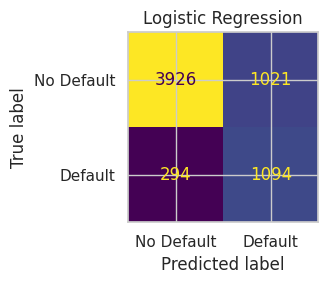


--------------------------------------------------
  Random Forest
--------------------------------------------------

Random Forest
Accuracy  : 0.9318
Precision : 0.9819
Recall    : 0.7017
F1-Score  : 0.8185
ROC-AUC   : 0.9317353281964617


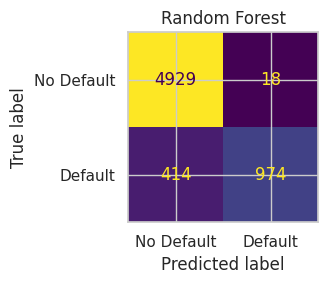


--------------------------------------------------
  XGBoost
--------------------------------------------------

XGBoost
Accuracy  : 0.9204
Precision : 0.8308
Recall    : 0.7997
F1-Score  : 0.8150
ROC-AUC   : 0.9495112165903825


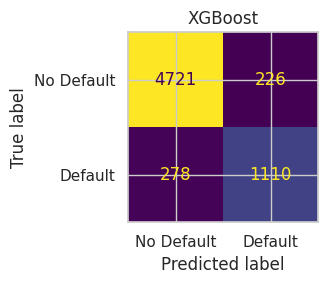


--------------------------------------------------
  Gradient Boosting
--------------------------------------------------

Gradient Boosting
Accuracy  : 0.9315
Precision : 0.9631
Recall    : 0.7147
F1-Score  : 0.8205
ROC-AUC   : 0.9314331335790504


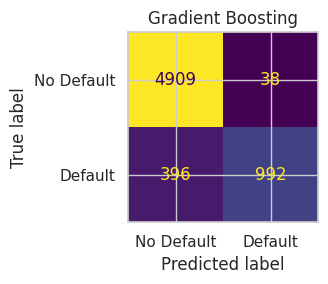


--------------------------------------------------
  Decision Tree
--------------------------------------------------

Decision Tree
Accuracy  : 0.8941
Precision : 0.7523
Recall    : 0.7702
F1-Score  : 0.7611
ROC-AUC   : 0.8495093378864961


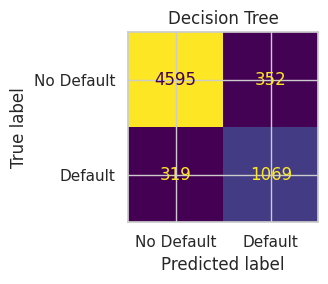

In [ ]:
models = {
    "Logistic Regression": linear_pipe,
    "Random Forest": rf_pipe,
    "XGBoost": xgb_pipe,
    "Gradient Boosting": gb_pipe,
    "Decision Tree": dt_pipe
}

results = []

for name, pipe in models.items():
     results.append(evaluate(name, pipe, X_train, y_train, X_test, y_test))

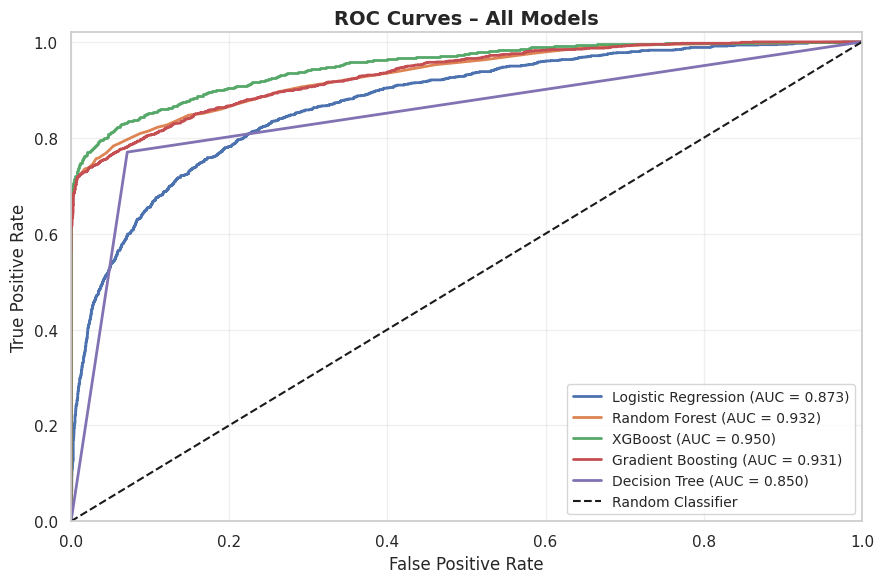

In [ ]:

# ROC CURVES – all models

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))
for name, pipe in models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- A higher ROC AUC means the model is better at distinguishing defaulters from non-defaulters.
- XGBoost has the highest ROC AUC ,the curve shows it consistently achieves higher true positive rates at lower false positive rates compared to other models.

In [ ]:
results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7924,0.5173,0.7882,0.6246,0.8735
Random Forest,0.9318,0.9819,0.7017,0.8185,0.9317
XGBoost,0.9204,0.8308,0.7997,0.8150,0.9495
Gradient Boosting,0.9315,0.9631,0.7147,0.8205,0.9314
Decision Tree,0.8941,0.7523,0.7702,0.7611,0.8495


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best ROC-AUC (CV): 0.9483
Best Parameters:
  model__subsample: 0.9
  model__n_estimators: 300
  model__min_child_weight: 1
  model__max_depth: 5
  model__learning_rate: 0.1
  model__gamma: 0
  model__colsample_bytree: 0.8

Tuned XGBoost – Test Set Performance:
  Accuracy  : 0.9219
  Precision : 0.8330
  Recall    : 0.8048
  F1-Score  : 0.8186
  ROC-AUC   : 0.9500

Classification Report:
               precision    recall  f1-score   support

  No Default       0.95      0.95      0.95      4947
     Default       0.83      0.80      0.82      1388

    accuracy                           0.92      6335
   macro avg       0.89      0.88      0.88      6335
weighted avg       0.92      0.92      0.92      6335



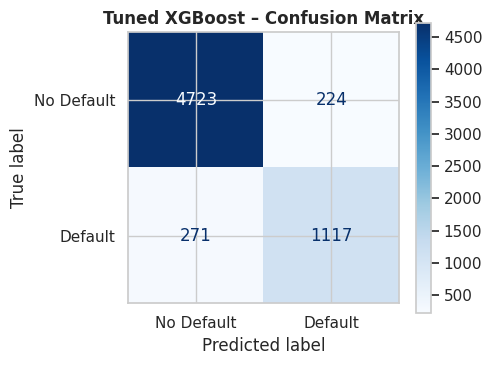

In [ ]:
#  HYPERPARAMETER TUNING – XGBoost (RandomizedSearchCV)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

param_dist = {
    'model__n_estimators':     [100, 200, 300, 500],
    'model__max_depth':        [3, 4, 5, 6, 7],
    'model__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'model__subsample':        [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma':            [0, 0.1, 0.2, 0.3],
}

xgb_pipe_tune = clone(xgb_pipe)

rscv = RandomizedSearchCV(
    estimator=xgb_pipe_tune,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)
rscv.fit(X_train, y_train)

print(f"\nBest ROC-AUC (CV): {rscv.best_score_:.4f}")
print("Best Parameters:")
for k, v in rscv.best_params_.items():
    print(f"  {k}: {v}")

best_xgb = rscv.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report
print("\nTuned XGBoost – Test Set Performance:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned,
      target_names=['No Default', 'Default']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title("Tuned XGBoost – Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# probability of the positive class (Default)
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# custom threshold
custom_threshold = 0.45
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# new Recall
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4947
           1       0.79      0.82      0.80      1388

    accuracy                           0.91      6335
   macro avg       0.87      0.88      0.87      6335
weighted avg       0.91      0.91      0.91      6335



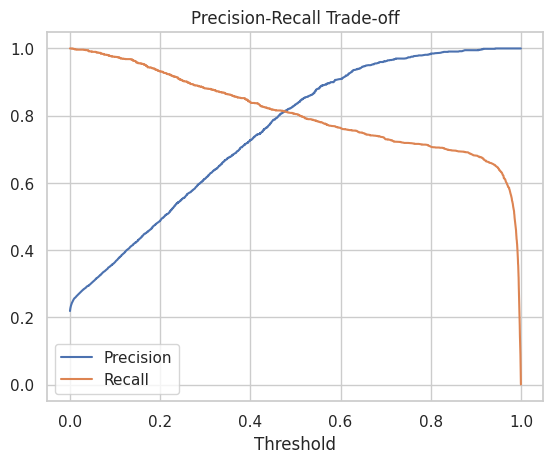

In [ ]:
#threshold plot
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.show()

Threshold Tuning is done to improve the usefulness of the model . Instead of relying on the default threshold it uses a threshold of 0.45 as it provides the best balance—improving recall without heavily sacrificing precision, which is critical for minimizing both missed defaults and false alarms.

 99%|===================| 6275/6335 [01:07<00:00]       

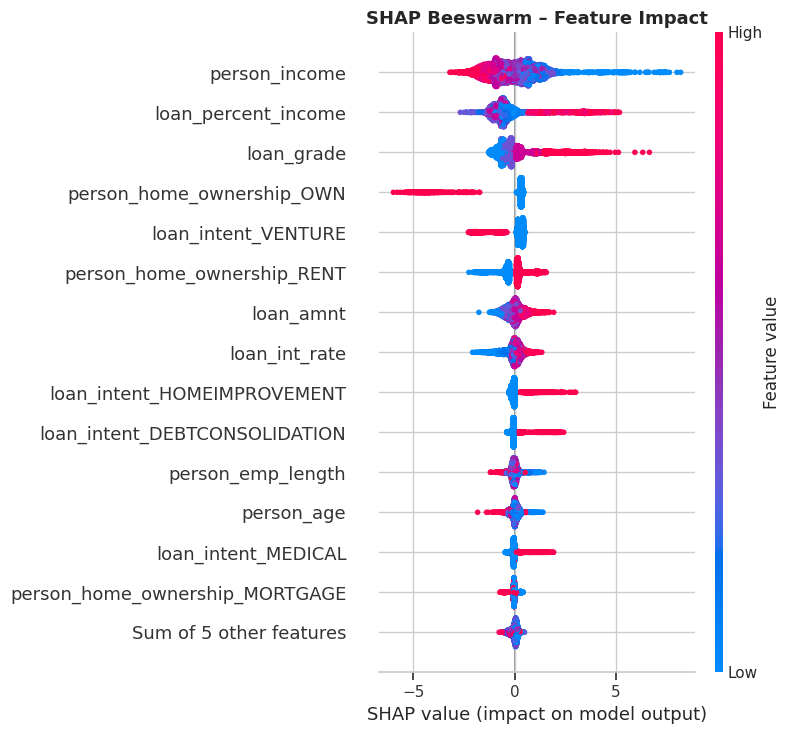

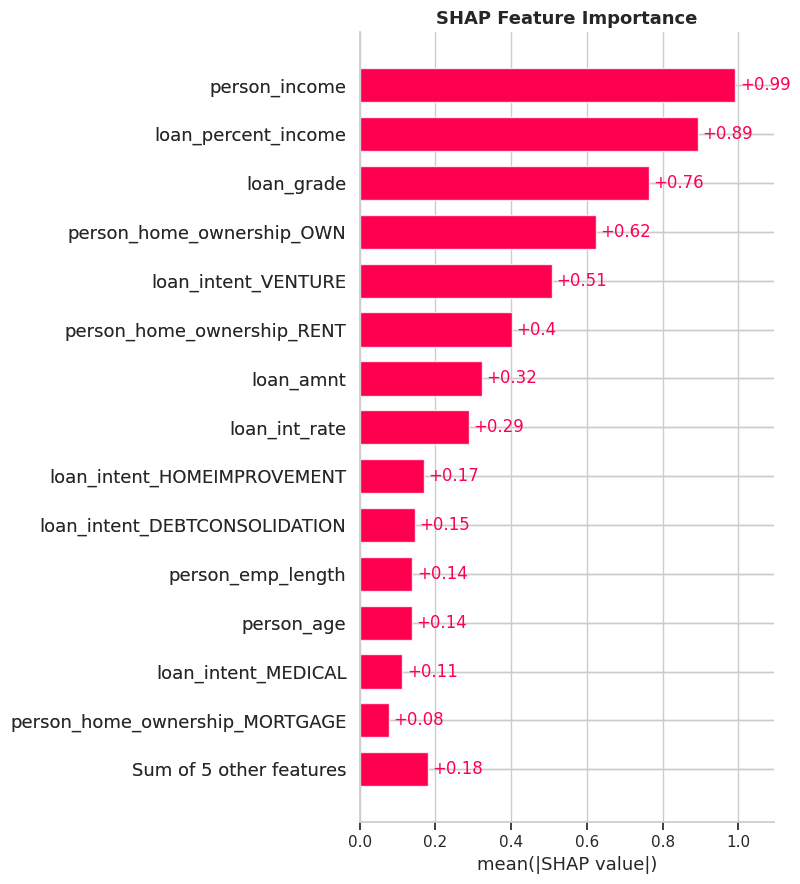

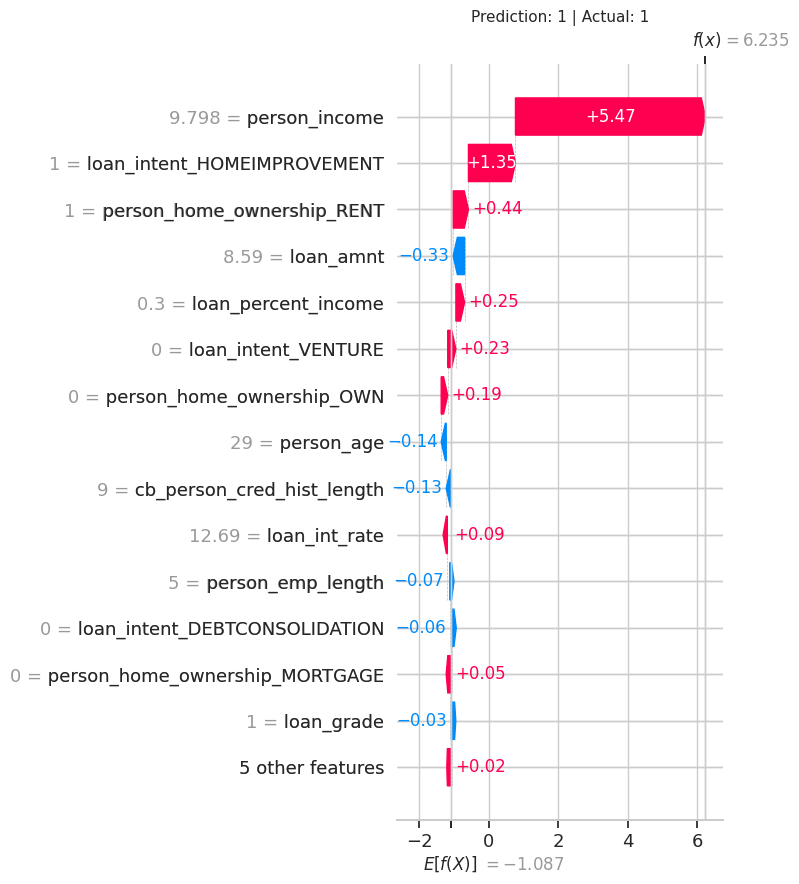

In [ ]:
import shap
import matplotlib.pyplot as plt

# Extract from pipeline
preprocessor = best_xgb.named_steps['preprocessor']
model = best_xgb.named_steps['model']

# transform dataset
X_test_transformed = preprocessor.transform(X_test)

# Keep as DataFrame
X_shap = X_test_transformed.copy()

# get feature names
clean_names = [col.split("__")[-1] for col in X_shap.columns]
X_shap.columns = clean_names

# SHAP Explainer
explainer = shap.Explainer(model, X_shap)
shap_values = explainer(X_shap)


#  BEESWARM plot

plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm – Feature Impact", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# BAR PLOT plot

plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# WATERFALL plot

sample_idx = 0

#prediction
prediction = best_xgb.predict(X_test.iloc[[sample_idx]])[0]
actual = y_test.iloc[sample_idx]

plt.figure()
shap.plots.waterfall(shap_values[sample_idx], max_display=15, show=False)
plt.title(f"Prediction: {prediction} | Actual: {actual}", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import joblib, shap, numpy as np


joblib.dump(best_xgb, 'final_xgb_model.pkl')
joblib.dump(0.45, "threshold.pkl")

#save SHAP explainer
preprocessor  = best_xgb.named_steps['preprocessor']
model         = best_xgb.named_steps['model']

X_sample      = preprocessor.transform(X_train.sample(500, random_state=42))
X_sample.columns = [c.split("__")[-1] for c in X_sample.columns]

explainer = shap.Explainer(model, X_sample)
joblib.dump(explainer, 'shap_explainer.pkl')

# Save feature names for streamlit
feature_names = list(X_sample.columns)
joblib.dump(feature_names, 'feature_names.pkl')

print("Saved: final_xgb_model.pkl | shap_explainer.pkl | feature_names.pkl")
print("Features:", feature_names)

Saved: final_xgb_model.pkl | shap_explainer.pkl | feature_names.pkl
Features: ['person_income', 'loan_amnt', 'loan_int_rate', 'person_emp_length', 'person_age', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file']


In [ ]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score


#  removed 'person_age' and 'cb_person_cred_hist_length'
log_cols_red = ['person_income', 'loan_amnt']
no_log_cols_red = ['loan_int_rate', 'person_emp_length', 'loan_percent_income'] # Removed 2 columns

#  new reduced preprocessor . This ensures the pipeline doesn't look for the missing columns
preprocessor_tree_red = ColumnTransformer([
    ('num_log', log_pipeline, log_cols_red),
    ('num_plain', standard_numeric_pipeline, no_log_cols_red),
    ('ord', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]), ordinal_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('bin', OrdinalEncoder(categories=[['N','Y']]), binary_cols)
])


xgb_pipe_red = Pipeline([
    ('preprocessor', preprocessor_tree_red),
    ('model', clone(best_xgb.named_steps['model'])) # Uses same XGB parameters
])

#fit predict
best_xgb.fit(X_train, y_train)
y_pred_full = best_xgb.predict_proba(X_test)[:, 1]
roc_full = roc_auc_score(y_test, y_pred_full)

# Reduced model
xgb_pipe_red.fit(X_train, y_train)
y_pred_red = xgb_pipe_red.predict_proba(X_test)[:, 1]
roc_red = roc_auc_score(y_test, y_pred_red)

print(f"ROC-AUC full: {roc_full:.4f}")
print(f"ROC-AUC reduced: {roc_red:.4f}")
print(f"Difference: {roc_full - roc_red:.4f}")


ROC-AUC full: 0.9500
ROC-AUC reduced: 0.9497
Difference: 0.0002


In [ ]:
threshold = 0.45

# Full model
y_pred_full_cls = (y_pred_full >= threshold).astype(int)

# Reduced model
y_pred_red_cls = (y_pred_red >= threshold).astype(int)

print("FULL MODEL")
print(classification_report(y_test, y_pred_full_cls))

print("REDUCED MODEL")
print(classification_report(y_test, y_pred_red_cls))

FULL MODEL
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4947
           1       0.79      0.82      0.80      1388

    accuracy                           0.91      6335
   macro avg       0.87      0.88      0.87      6335
weighted avg       0.91      0.91      0.91      6335

REDUCED MODEL
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      4947
           1       0.78      0.82      0.80      1388

    accuracy                           0.91      6335
   macro avg       0.86      0.88      0.87      6335
weighted avg       0.91      0.91      0.91      6335



I experimented with feature reduction by removing two low-impact features, `person_age` and `cb_person_cred_hist_length`. The reduced model showed negligible change in ROC-AUC and classification metrics, indicating that these features had minimal contribution and offered no significant practical gain. Given that this is a credit risk model where even small improvements in predictive performance are valuable, I retained the full model for the final implementation.